[0.04967860010045237, 0.9672695865611625]


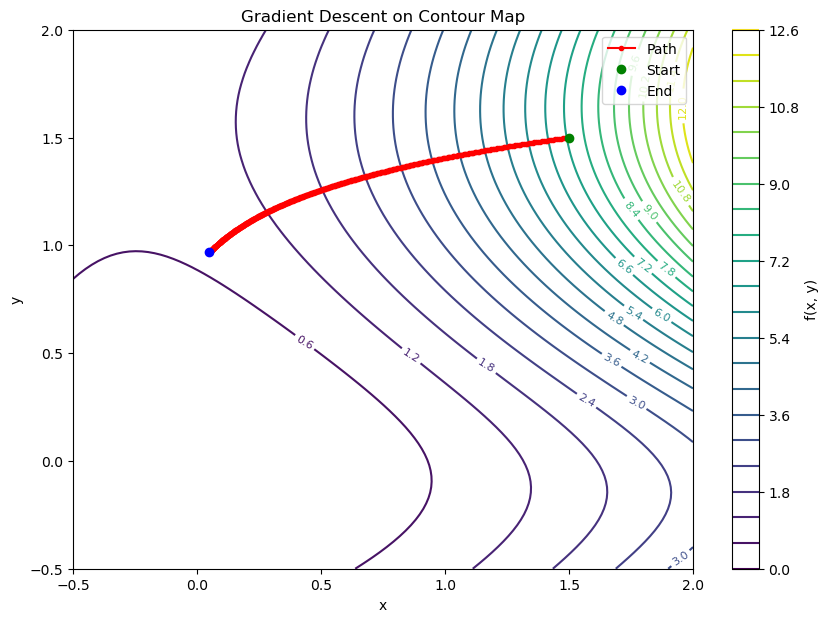

In [11]:
import math
import matplotlib.pyplot as plt
import numpy as np

def f(inpts):
    return (np.exp(inpts[0]))*(np.sin(inpts[1])**2) + (inpts[0]**2)*(np.log(inpts[1]+2))

def f_gradient(inpts):
    return [(2*inpts[0])*(np.log(inpts[1]+2)) + (np.exp(inpts[0]))*(np.sin(inpts[1])**2), ((inpts[0]**2)/(2+inpts[1])) + np.exp(inpts[0])*np.sin(2*inpts[1])]

def simplified_f(x, y):
    return f([x, y])

a = 0.001
eps = 0.01

start = [1.5, 1.5]

all_values = [[x for x in start] + [f(start)]]

values = [x for x in start]

for _ in range(500):
    gradient = f_gradient(values)
    values = [values[i] - gradient[i]*a for i in range(len(values))]
    all_values.append(values + [f(values)])
    if abs(f(values)) < eps:
        break

print(values)

# --- Plotting ---
path = np.array(all_values)

# 1. Create a grid of points
x_range = np.linspace(-0.5, 2.0, 100)
y_range = np.linspace(-0.5, 2.0, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f([X, Y])

plt.figure(figsize=(10, 7))

# 2. Plot the contour lines
contours = plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

# 3. Plot the gradient descent path
plt.plot(path[:, 0], path[:, 1], color='red', marker='o', markersize=3, label='Path')
plt.plot(start[0], start[1], 'go', label='Start') # Green start
plt.plot(values[0], values[1], 'bo', label='End')   # Blue end

plt.title('Gradient Descent on Contour Map')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.colorbar(label='f(x, y)')
plt.show()